In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# for xgboost only 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score

import optuna

In [16]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



df=pd.read_csv("../../data/Crop_recommendation.csv")


X=df.drop(columns="label")
y=df["label"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)



scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

label_encoder = LabelEncoder()

y_train_xgb = label_encoder.fit_transform(y_train)
y_test_xgb = label_encoder.transform(y_test)

In [17]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    
    "KNN": KNeighborsClassifier(),
    
    "SVM": SVC(),
    
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    
    "Random Forest": RandomForestClassifier(random_state=42),
    
    
    
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),
    
    "LightGBM": LGBMClassifier(
        random_state=42,
        verbose=-1
    ),
    
    "CatBoost": CatBoostClassifier(
        random_state=42,
        verbose=0
    )
}

In [18]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(
    X_train_scaled,
    y_train_xgb
)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklear

In [19]:
for name, model in models.items():
    print(f"Training {name}...")
    
    model.fit(X_train_scaled, y_train)
    
    print(f"{name} trained successfully.\n")

Training Logistic Regression...
Logistic Regression trained successfully.

Training KNN...
KNN trained successfully.

Training SVM...
SVM trained successfully.

Training Decision Tree...
Decision Tree trained successfully.

Training Random Forest...
Random Forest trained successfully.

Training Gradient Boosting...
Gradient Boosting trained successfully.

Training LightGBM...
LightGBM trained successfully.

Training CatBoost...
CatBoost trained successfully.



In [20]:
from sklearn.metrics import accuracy_score

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test, y_pred)   
    
    results[name] = accuracy
    
    print(f"{name}: {accuracy:.4f}")

Logistic Regression: 0.9727
KNN: 0.9795
SVM: 0.9841
Decision Tree: 0.9795
Random Forest: 0.9955
Gradient Boosting: 0.9886
LightGBM: 0.9886
CatBoost: 0.9977


In [21]:
results_df = pd.DataFrame(
    list(results.items()),
    columns=["Model", "Accuracy"]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy
7,CatBoost,0.997727
4,Random Forest,0.995455
6,LightGBM,0.988636
5,Gradient Boosting,0.988636
2,SVM,0.984091
1,KNN,0.979545
3,Decision Tree,0.979545
0,Logistic Regression,0.972727


In [22]:
xgb_pred = xgb_model.predict(X_test_scaled)

print(xgb_pred[:10])

[16  1  6 11 16  3 20  2  1 16]


In [23]:
xgb_pred_labels = label_encoder.inverse_transform(xgb_pred)

print(xgb_pred_labels[:10])

['orange' 'banana' 'cotton' 'maize' 'orange' 'chickpea' 'rice' 'blackgram'
 'banana' 'orange']


In [25]:
xgb_accuracy = accuracy_score(y_test_xgb, xgb_pred)
xgb_accuracy

0.990909090909091

optuna tuning


1.CatBoost

In [35]:
def objective(trial):

    params = {
        "iterations": trial.suggest_int("iterations", 200, 800),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.3, log=True
        ),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg", 1, 10
        ),
        "border_count": trial.suggest_int(
            "border_count", 32, 128
        ),
        "random_strength": trial.suggest_float(
            "random_strength", 0, 2
        ),
        "loss_function": "MultiClass",
        "verbose": 0,
        "random_seed": 42,
        "thread_count": 2
    }

    model = CatBoostClassifier(**params)

    cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=1
    )

    return scores.mean()

In [36]:
study = optuna.create_study(
    direction="maximize",
    study_name="catboost_crop",
    storage="sqlite:///catboost_crop.db",
    load_if_exists=True
)

study.optimize(
    objective,
    n_trials=30
)

[I 2026-08-26 15:03:09,767] A new study created in RDB with name: catboost_crop
[I 2026-08-26 15:03:47,880] Trial 0 finished with value: 0.9823876443147218 and parameters: {'iterations': 670, 'learning_rate': 0.010585631766766109, 'depth': 7, 'l2_leaf_reg': 9.214550666713917, 'border_count': 50, 'random_strength': 1.7360094210826942}. Best is trial 0 with value: 0.9823876443147218.
[I 2026-08-26 15:03:59,998] Trial 1 finished with value: 0.98750031493896 and parameters: {'iterations': 383, 'learning_rate': 0.0382662448259088, 'depth': 5, 'l2_leaf_reg': 4.360672098049611, 'border_count': 100, 'random_strength': 1.9910955497709502}. Best is trial 1 with value: 0.98750031493896.
[I 2026-08-26 15:04:34,794] Trial 2 finished with value: 0.9897736897085702 and parameters: {'iterations': 608, 'learning_rate': 0.11985114878285365, 'depth': 6, 'l2_leaf_reg': 8.27809621547227, 'border_count': 122, 'random_strength': 1.484432046353706}. Best is trial 2 with value: 0.9897736897085702.
[I 2026-08-2

In [37]:
print(study.best_value)
print(study.best_params)

0.9914762981783931
{'iterations': 309, 'learning_rate': 0.17854008450257314, 'depth': 7, 'l2_leaf_reg': 2.970724520543527, 'border_count': 54, 'random_strength': 0.35017104375338404}


In [38]:
best_catboost = CatBoostClassifier(
    **study.best_params,
    loss_function="MultiClass",
    verbose=0,
    random_seed=42
)

best_catboost.fit(
    X_train_scaled,
    y_train
)

CatBoostClassifier(border_count=54, depth=7, iterations=309, l2_leaf_reg=2.970724520543527, learning_rate=0.17854008450257314, loss_function='MultiClass', random_seed=42, random_strength=0.35017104375338404, verbose=0)

In [39]:
from sklearn.metrics import accuracy_score

y_pred_catboost = best_catboost.predict(X_test_scaled)

catboost_tuned_accuracy = accuracy_score(
    y_test,
    y_pred_catboost
)

print(
    f"Tuned CatBoost Accuracy: "
    f"{catboost_tuned_accuracy:.4f}"
)

print(
    f"Tuned CatBoost Accuracy: "
    f"{catboost_tuned_accuracy * 100:.2f}%"
)

Tuned CatBoost Accuracy: 0.9909
Tuned CatBoost Accuracy: 99.09%


In [40]:
print("Baseline CatBoost :", 99.7727)
print(
    "Tuned CatBoost    :",
    catboost_tuned_accuracy * 100
)

Baseline CatBoost : 99.7727
Tuned CatBoost    : 99.0909090909091


Random Forest

In [41]:
def objective_rf(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 500
        ),
        "max_depth": trial.suggest_int(
            "max_depth", 5, 30
        ),
        "min_samples_split": trial.suggest_int(
            "min_samples_split", 2, 10
        ),
        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf", 1, 5
        ),
        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", None]
        ),
        "criterion": trial.suggest_categorical(
            "criterion", ["gini", "entropy", "log_loss"]
        ),
        "random_state": 42,
        "n_jobs": 2
    }

    model = RandomForestClassifier(**params)

    cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=1
    )

    return scores.mean()

In [42]:
study_rf = optuna.create_study(
    direction="maximize",
    study_name="random_forest_crop",
    storage="sqlite:///randomforest_crop.db",
    load_if_exists=True
)

study_rf.optimize(
    objective_rf,
    n_trials=30
)

[I 2026-08-26 15:18:03,466] A new study created in RDB with name: random_forest_crop
[I 2026-08-26 15:18:08,304] Trial 0 finished with value: 0.9840921908704526 and parameters: {'n_estimators': 399, 'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': None, 'criterion': 'entropy'}. Best is trial 0 with value: 0.9840921908704526.
[I 2026-08-26 15:18:11,905] Trial 1 finished with value: 0.9852288782552575 and parameters: {'n_estimators': 385, 'max_depth': 16, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': None, 'criterion': 'gini'}. Best is trial 1 with value: 0.9852288782552575.
[I 2026-08-26 15:18:14,060] Trial 2 finished with value: 0.9897736897085702 and parameters: {'n_estimators': 305, 'max_depth': 27, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'criterion': 'log_loss'}. Best is trial 2 with value: 0.9897736897085702.
[I 2026-08-26 15:18:18,701] Trial 3 finished with value: 0.9840921908704526 and parameters: {'n_

In [44]:
print(study_rf.best_value)
print(study_rf.best_params)

0.9926139546061519
{'n_estimators': 367, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'gini'}


In [45]:
best_rf = RandomForestClassifier(
    **study_rf.best_params,
    random_state=42,
    n_jobs=2
)

best_rf.fit(
    X_train_scaled,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",367
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [46]:
from sklearn.metrics import accuracy_score

y_pred_rf = best_rf.predict(X_test_scaled)

rf_tuned_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print(f"Tuned Random Forest Accuracy: {rf_tuned_accuracy:.4f}")
print(f"Tuned Random Forest Accuracy: {rf_tuned_accuracy * 100:.2f}%")

Tuned Random Forest Accuracy: 0.9932
Tuned Random Forest Accuracy: 99.32%


In [48]:
print("Baseline RF :", 99.5455)
print("Tuned RF    :", rf_tuned_accuracy * 100)

Baseline RF : 99.5455
Tuned RF    : 99.31818181818181


XGBoost

In [49]:
def objective_xgb(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 800
        ),
        "max_depth": trial.suggest_int(
            "max_depth", 3, 10
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.3, log=True
        ),
        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),
        "min_child_weight": trial.suggest_int(
            "min_child_weight", 1, 10
        ),
        "gamma": trial.suggest_float(
            "gamma", 0, 5
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha", 0, 5
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1, 10
        ),
        "objective": "multi:softmax",
        "eval_metric": "mlogloss",
        "random_state": 42,
        "n_jobs": 2
    }

    model = XGBClassifier(**params)

    cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train_xgb,
        cv=cv,
        scoring="accuracy",
        n_jobs=1
    )

    return scores.mean()

In [50]:
study_xgb = optuna.create_study(
    direction="maximize",
    study_name="xgboost_crop",
    storage="sqlite:///xgboost_crop.db",
    load_if_exists=True
)

study_xgb.optimize(
    objective_xgb,
    n_trials=30
)

[I 2026-08-26 15:23:17,400] A new study created in RDB with name: xgboost_crop
[I 2026-08-26 15:23:25,892] Trial 0 finished with value: 0.9835253007424808 and parameters: {'n_estimators': 644, 'max_depth': 8, 'learning_rate': 0.029262133544062804, 'subsample': 0.9540387982438417, 'colsample_bytree': 0.9281542758951676, 'min_child_weight': 8, 'gamma': 0.09780121330219438, 'reg_alpha': 3.8616059405400147, 'reg_lambda': 2.158262190912169}. Best is trial 0 with value: 0.9835253007424808.
[I 2026-08-26 15:23:32,254] Trial 1 finished with value: 0.9755675200058919 and parameters: {'n_estimators': 764, 'max_depth': 10, 'learning_rate': 0.01611730573619047, 'subsample': 0.7876018024581184, 'colsample_bytree': 0.9615331717970954, 'min_child_weight': 6, 'gamma': 4.120334576422271, 'reg_alpha': 4.044259892559735, 'reg_lambda': 2.2739779581240414}. Best is trial 0 with value: 0.9835253007424808.
[I 2026-08-26 15:23:36,357] Trial 2 finished with value: 0.9772769117763914 and parameters: {'n_estimat

In [56]:
print(study_xgb.best_value)
print(study_xgb.best_params)

0.99204706447818
{'n_estimators': 603, 'max_depth': 5, 'learning_rate': 0.028080290557015542, 'subsample': 0.9648034445910404, 'colsample_bytree': 0.6796639001195752, 'min_child_weight': 1, 'gamma': 1.169118410919317, 'reg_alpha': 0.22112712017668235, 'reg_lambda': 5.027400577910852}


In [57]:
best_xgb = XGBClassifier(
    **study_xgb.best_params,
    objective="multi:softmax",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=2
)

best_xgb.fit(
    X_train_scaled,
    y_train_xgb
)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6796639001195752
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: pytho

In [59]:
from sklearn.metrics import accuracy_score

y_pred_xgb = best_xgb.predict(X_test_scaled)

xgb_tuned_accuracy = accuracy_score(
    y_test_xgb,
    y_pred_xgb
)

print(f"Tuned XGBoost Accuracy: {xgb_tuned_accuracy:.4f}")
print(f"Tuned XGBoost Accuracy: {xgb_tuned_accuracy * 100:.2f}%")

Tuned XGBoost Accuracy: 0.9909
Tuned XGBoost Accuracy: 99.09%


In [60]:
print("Baseline XGBoost :", 99.09)
print("Tuned XGBoost    :", xgb_tuned_accuracy * 100)

Baseline XGBoost : 99.09
Tuned XGBoost    : 99.0909090909091


Light GBM

In [61]:
def objective_lgbm(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 800
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.3, log=True
        ),
        "max_depth": trial.suggest_int(
            "max_depth", 3, 12
        ),
        "num_leaves": trial.suggest_int(
            "num_leaves", 15, 150
        ),
        "min_child_samples": trial.suggest_int(
            "min_child_samples", 5, 50
        ),
        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha", 0, 5
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda", 0, 10
        ),
        "random_state": 42,
        "n_jobs": 2,
        "verbosity": -1
    }

    model = LGBMClassifier(**params)

    cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=1
    )

    return scores.mean()

In [62]:
study_lgbm = optuna.create_study(
    direction="maximize",
    study_name="lightgbm_crop",
    storage="sqlite:///xgboost_crop.db",
    load_if_exists=True
)

study_lgbm.optimize(
    objective_lgbm,
    n_trials=30
)

[I 2026-08-26 15:28:32,184] A new study created in RDB with name: lightgbm_crop
[I 2026-08-26 15:28:34,006] Trial 0 finished with value: 0.9931827828200314 and parameters: {'n_estimators': 455, 'learning_rate': 0.12324163312981644, 'max_depth': 7, 'num_leaves': 81, 'min_child_samples': 48, 'subsample': 0.9856560617793532, 'colsample_bytree': 0.6424796817063868, 'reg_alpha': 2.3102690171939146, 'reg_lambda': 7.441799993621856}. Best is trial 0 with value: 0.9931827828200314.
[I 2026-08-26 15:28:36,582] Trial 1 finished with value: 0.9926129855631981 and parameters: {'n_estimators': 412, 'learning_rate': 0.014100277793492785, 'max_depth': 7, 'num_leaves': 106, 'min_child_samples': 10, 'subsample': 0.6965001042722666, 'colsample_bytree': 0.7078280299251545, 'reg_alpha': 4.111173654529748, 'reg_lambda': 3.460845808872831}. Best is trial 0 with value: 0.9931827828200314.
[I 2026-08-26 15:28:38,361] Trial 2 finished with value: 0.9875022530248675 and parameters: {'n_estimators': 513, 'learni

In [64]:
print(study_lgbm.best_value)
print(study_lgbm.best_params)    

0.9948863603328082
{'n_estimators': 365, 'learning_rate': 0.014269809120924603, 'max_depth': 8, 'num_leaves': 22, 'min_child_samples': 5, 'subsample': 0.619317942412676, 'colsample_bytree': 0.6800092430676696, 'reg_alpha': 3.226539366304329, 'reg_lambda': 6.324929412624578}


In [65]:
best_lgbm = LGBMClassifier(
    **study_lgbm.best_params,
    random_state=42,
    n_jobs=2,
    verbosity=-1
)

best_lgbm.fit(
    X_train_scaled,
    y_train
)

,num_leaves,22
,max_depth,8
,learning_rate,0.014269809120924603
,n_estimators,365
,min_child_samples,5
,subsample,0.619317942412676
,colsample_bytree,0.6800092430676696
,reg_alpha,3.226539366304329
,reg_lambda,6.324929412624578
,random_state,42
,n_jobs,2


In [66]:
from sklearn.metrics import accuracy_score

y_pred_lgbm = best_lgbm.predict(X_test_scaled)

lgbm_tuned_accuracy = accuracy_score(
    y_test,
    y_pred_lgbm
)

print(
    f"Tuned LightGBM Accuracy: "
    f"{lgbm_tuned_accuracy:.4f}"
)

print(
    f"Tuned LightGBM Accuracy: "
    f"{lgbm_tuned_accuracy * 100:.2f}%"
)

Tuned LightGBM Accuracy: 0.9932
Tuned LightGBM Accuracy: 99.32%


In [67]:
print("Baseline LightGBM :", 98.8636)
print("Tuned LightGBM    :", lgbm_tuned_accuracy * 100)

Baseline LightGBM : 98.8636
Tuned LightGBM    : 99.31818181818181


In [68]:
comparison = pd.DataFrame({
    "Model": [
        "CatBoost",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],
    
    "Baseline Accuracy (%)": [
        99.7727,
        99.5455,
        99.09,
        98.8636
    ],
    
    "Optuna Accuracy (%)": [
        catboost_tuned_accuracy * 100,
        rf_tuned_accuracy * 100,
        xgb_tuned_accuracy * 100,
        lgbm_tuned_accuracy * 100
    ]
})

comparison["Improvement (%)"] = (
    comparison["Optuna Accuracy (%)"]
    - comparison["Baseline Accuracy (%)"]
)

comparison = comparison.sort_values(
    by="Optuna Accuracy (%)",
    ascending=False
).reset_index(drop=True)

comparison

,Model,Baseline Accuracy (%),Optuna Accuracy (%),Improvement (%)
0,Random Forest,99.5455,99.318182,-0.227318
1,LightGBM,98.8636,99.318182,0.454582
2,CatBoost,99.7727,99.090909,-0.681791
3,XGBoost,99.0900,99.090909,0.000909


In [80]:
# final_model = models["CatBoost"]

Final model: CatBoostClassifier

Final model classes:
['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']

Actual test labels:
label
apple          20
banana         20
blackgram      20
chickpea       20
coconut        20
coffee         20
cotton         20
grapes         20
jute           20
kidneybeans    20
lentil         20
maize          20
mango          20
mothbeans      20
mungbean       20
muskmelon      20
orange         20
papaya         20
pigeonpeas     20
pomegranate    20
rice           20
watermelon     20
Name: count, dtype: int64

Final model predictions:
apple          20
banana         20
blackgram      20
chickpea       20
coconut        20
coffee         20
cotton         20
grapes         20
jute           21
kidneybeans    20
lentil         20
maize          20
mango          20
mothbeans

baseline model of catboost is the best

In [81]:
from catboost import CatBoostClassifier

final_model = CatBoostClassifier(
    random_state=42,
    verbose=0
)

final_model.fit(
    X_train_scaled,
    y_train
)

CatBoostClassifier(random_state=42, verbose=0)

In [82]:
y_pred = final_model.predict(X_test_scaled)

In [84]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall    : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1 Score  : {f1:.4f} ({f1*100:.2f}%)")

Accuracy  : 0.9977 (99.77%)
Precision : 0.9978 (99.78%)
Recall    : 0.9977 (99.77%)
F1 Score  : 0.9977 (99.77%)


In [85]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

In [87]:
print("Final model:", type(final_model).__name__)

print("\nFinal model classes:")
print(final_model.classes_)

print("\nActual test labels:")
print(y_test.value_counts().sort_index())

final_pred = final_model.predict(X_test_scaled)

# Convert predictions to 1D
final_pred = final_pred.ravel()

print("\nFinal model predictions:")
print(pd.Series(final_pred).value_counts().sort_index())

print("\nFinal model accuracy:")
print(accuracy_score(y_test, final_pred))

Final model: CatBoostClassifier

Final model classes:
['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']

Actual test labels:
label
apple          20
banana         20
blackgram      20
chickpea       20
coconut        20
coffee         20
cotton         20
grapes         20
jute           20
kidneybeans    20
lentil         20
maize          20
mango          20
mothbeans      20
mungbean       20
muskmelon      20
orange         20
papaya         20
pigeonpeas     20
pomegranate    20
rice           20
watermelon     20
Name: count, dtype: int64

Final model predictions:
apple          20
banana         20
blackgram      20
chickpea       20
coconut        20
coffee         20
cotton         20
grapes         20
jute           21
kidneybeans    20
lentil         20
maize          20
mango          20
mothbeans

In [88]:
for name, trained_model in models.items():
    pred = trained_model.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred)
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.9727
KNN: 0.9795
SVM: 0.9841
Decision Tree: 0.9795
Random Forest: 0.9955
Gradient Boosting: 0.9886
LightGBM: 0.9886
CatBoost: 0.9977


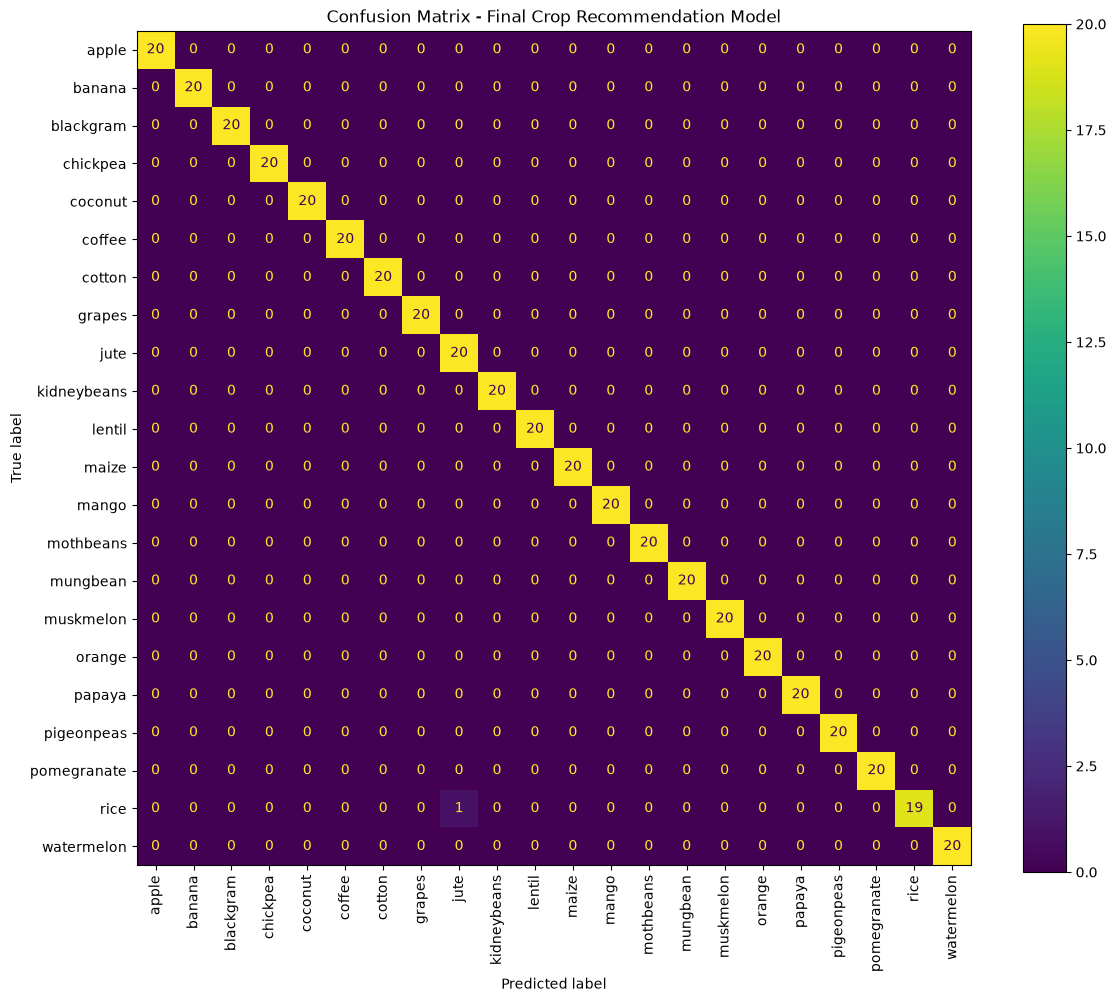

In [89]:
final_pred = final_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, final_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=final_model.classes_
)

fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, xticks_rotation=90)

plt.title("Confusion Matrix - Final Crop Recommendation Model")
plt.tight_layout()
plt.show()

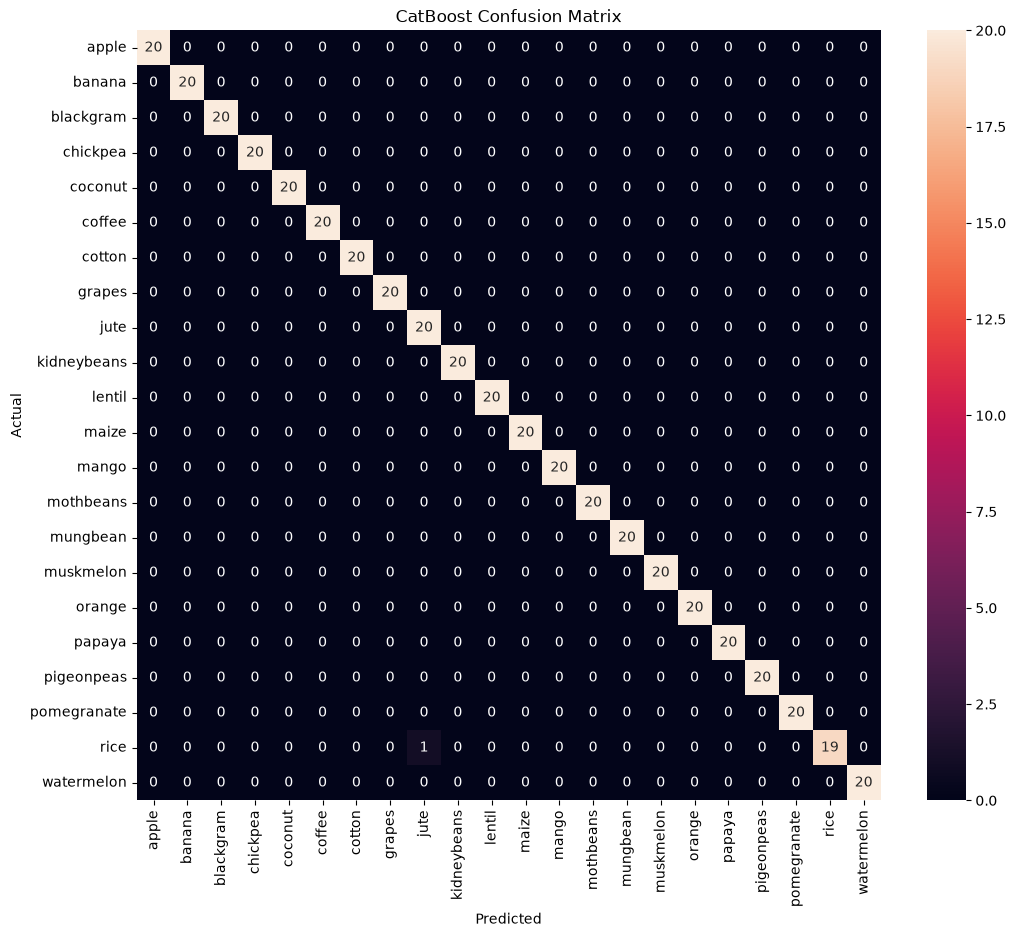

In [86]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=final_model.classes_,
    yticklabels=final_model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CatBoost Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

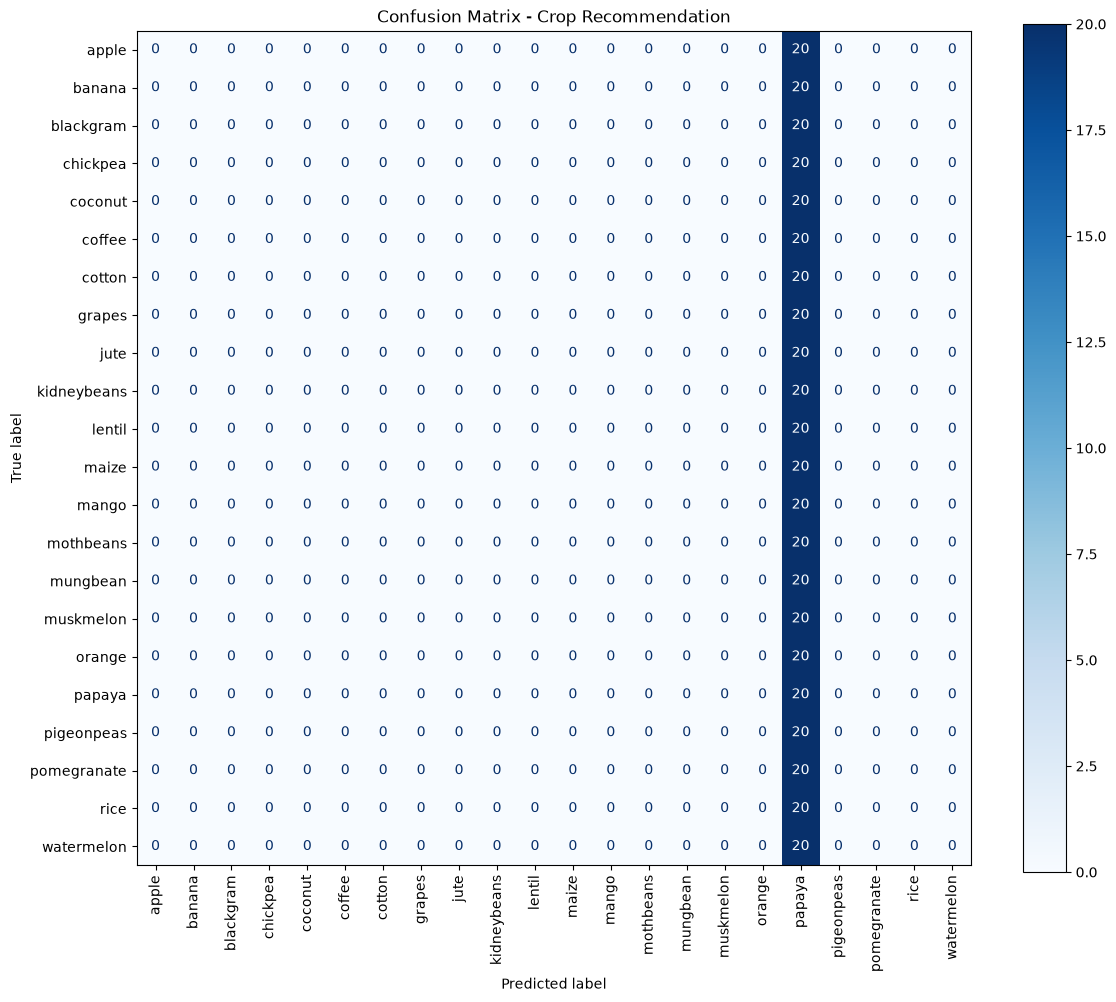

In [75]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, xticks_rotation=90, cmap="Blues")

plt.title("Confusion Matrix - Crop Recommendation")
plt.tight_layout()
plt.show()

In [90]:
# check for overfitting
from sklearn.metrics import accuracy_score

# Training predictions
train_pred = final_model.predict(X_train_scaled)

# Test predictions
test_pred = final_model.predict(X_test_scaled)

# Accuracy
train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy:     {test_accuracy:.4f}")

print(f"\nTraining Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy:     {test_accuracy * 100:.2f}%")

print(f"\nAccuracy Gap: {(train_accuracy - test_accuracy) * 100:.2f}%")

Training Accuracy: 1.0000
Test Accuracy:     0.9977

Training Accuracy: 100.00%
Test Accuracy:     99.77%

Accuracy Gap: 0.23%


In [99]:
import pickle
import os

os.makedirs("../../models", exist_ok=True)

# Save CatBoost model
with open("../../models/crop_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

# Save scaler
with open("../../models/crop_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save label encoder
with open("../../models/crop_label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("All crop model files saved successfully!")

All crop model files saved successfully!
